Group Name: E  
Members: Ronald Y. Perez Mendez (Big E), Victor E. Ravelo Santana (Smol E) & Elvin J. Rodriguez Jimenez (THE E)  
Course: ICOM5015-001D  
Date: 25/2/2026

Purpose: This is assignment is to test the speed between python and numPy 

Python Fast or Slow?

In [6]:
import numpy as np
import time
import statistics
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

Pure Python

In [7]:
def python_vector_multiply(a, b):
    result = []
    for i in range(len(a)):
        result.append(a[i] * b[i])
    return result

In [8]:
def python_matrix_multiply(A, B):
    n = len(A)
    m = len(B[0])
    p = len(B)

    result = [[0.0 for _ in range(m)] for _ in range(n)]

    for i in range(n):
        for j in range(m):
            for k in range(p):
                result[i][j] += A[i][k] * B[k][j]

    return result

Numpy

In [9]:
def numpy_vector_multiply(a, b):
    return a * b

def numpy_matrix_multiply(A, B):
    return A @ B

Benchmark Section 

In [10]:
dimensions = [10 , 50, 100, 200, 500]


python_times = []        # matrix medians
numpy_times  = []        # matrix medians
python_times_vec = []    # vector medians
numpy_times_vec  = []    # vector medians

for n in dimensions:
    # Create matrices
    A_np = np.random.rand(n, n).astype(np.float64)
    B_np = np.random.rand(n, n).astype(np.float64)

    A_py = A_np.tolist()
    B_py = B_np.tolist()  

    # Create vectors
    a_np = np.random.rand(n).astype(np.float64)
    b_np = np.random.rand(n).astype(np.float64)

    a_py = a_np.tolist()
    b_py = b_np.tolist()

    # ------- NumPy timing Matrix -------
    numpy_matrix_multiply(A_np, B_np)  # warm-up 

    times = []
    for _ in range(10):
        t0 = time.perf_counter()
        numpy_matrix_multiply(A_np, B_np)   # time ONLY this
        t1 = time.perf_counter()
        times.append(t1 - t0)

    numpy_times.append(statistics.median(times))

     # ------- NumPy timing Vector-------
    numpy_vector_multiply(a_np, b_np)  # warm-up

    times = []
    for _ in range(10):
        t0 = time.perf_counter()
        numpy_vector_multiply(a_np, b_np)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    numpy_times_vec.append(statistics.median(times))

    # ------- Pure Python Matrix timing -------

    python_matrix_multiply(A_py, B_py)  # warm-up

    times = []
    for _ in range(10):
        t0 = time.perf_counter()
        python_matrix_multiply(A_py, B_py)  # time ONLY this
        t1 = time.perf_counter()
        times.append(t1 - t0)

    python_times.append(statistics.median(times))

     # ------- Pure Python Vector timing -------
    python_vector_multiply(a_py, b_py)  # warm-up

    times = []
    for _ in range(10):
        t0 = time.perf_counter()
        python_vector_multiply(a_py, b_py)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    python_times_vec.append(statistics.median(times))



print("dims:", dimensions)
print("matrix python:", python_times)
print("matrix numpy:", numpy_times)
print("vector python:", python_times_vec)
print("vector numpy:", numpy_times_vec)

dims: [10, 50, 100, 200, 500]
matrix python: [8.950004121288657e-05, 0.010044950002338737, 0.09483834996353835, 0.6595310500124469, 13.492549950024113]
matrix numpy: [1.8499558791518211e-06, 1.379998866468668e-05, 0.00018904992612078786, 0.0006314500351436436, 0.003692900005262345]
vector python: [7.500057108700275e-07, 2.7500209398567677e-06, 5.54998405277729e-06, 1.0000017937272787e-05, 2.56500206887722e-05]
vector numpy: [8.00006091594696e-07, 6.00004568696022e-07, 7.00005330145359e-07, 8.500064723193645e-07, 8.500064723193645e-07]


Correctness Verification

In [11]:


n_test = dimensions[-1]  # use largest size

# Matrices
A_np = np.random.rand(n_test, n_test).astype(np.float64)
B_np = np.random.rand(n_test, n_test).astype(np.float64)
A_py = A_np.tolist()
B_py = B_np.tolist()

# Vectors
a_np = np.random.rand(n_test).astype(np.float64)
b_np = np.random.rand(n_test).astype(np.float64)
a_py = a_np.tolist()
b_py = b_np.tolist()

# Matrix comparison
python_matrix = python_matrix_multiply(A_py, B_py)
numpy_matrix = numpy_matrix_multiply(A_np, B_np)

print("Matrix correct:",
      np.allclose(np.array(python_matrix), numpy_matrix))

# Vector comparison
python_vector = python_vector_multiply(a_py, b_py)
numpy_vector = numpy_vector_multiply(a_np, b_np)

print("Vector correct:",
      np.allclose(np.array(python_vector), numpy_vector))

Matrix correct: True
Vector correct: True


Plot Execution Time vs Size

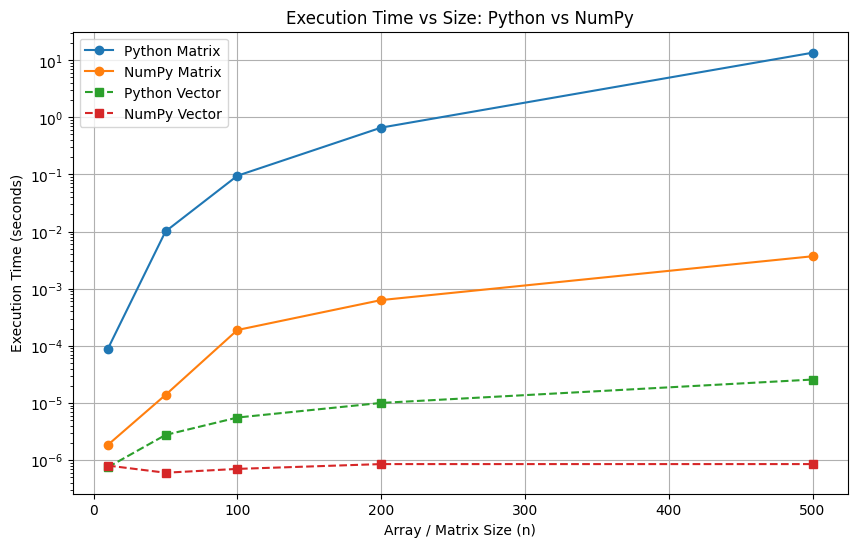

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# ----- Matrix -----
plt.plot(dimensions, python_times, 'o-', label="Python Matrix")
plt.plot(dimensions, numpy_times, 'o-', label="NumPy Matrix")

# ----- Vector -----
plt.plot(dimensions, python_times_vec, 's--', label="Python Vector")
plt.plot(dimensions, numpy_times_vec, 's--', label="NumPy Vector")

plt.xlabel("Array / Matrix Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time vs Size: Python vs NumPy")
plt.legend()
plt.grid(True)

plt.yscale("log")  # strongly recommended

plt.show()

Observed Trends
From the experimental results:

    Execution time increases as the array/matrix size increases.

    Pure Python matrix multiplication grows extremely fast, reaching more than 13 seconds at size 500.

    NumPy matrix multiplication remains very low, staying below 0.004 seconds even at size 500.

    The performance gap increases dramatically as size increases.

For vector operations:

    Python vector time increases gradually.

    NumPy vector time remains almost constant (~8e-07 seconds).

    The difference is smaller than matrices but NumPy is still faster.

The matrix case clearly shows exponential growth behavior in Pure Python compared to a much more efficient scaling in NumPy.

Why NumPy Is Faster
NumPy is significantly faster because:

    It is implemented in compiled C and Fortran, not pure Python.

    Matrix multiplication uses optimized numerical libraries such as BLAS/LAPACK.

    Pure Python uses nested loops, which:

    Add interpreter overhead

        Perform dynamic type checking

        Have inefficient memory access

    NumPy arrays use contiguous memory layout, improving CPU cache performance.

In matrix multiplication, Python executes millions of interpreted operations, while NumPy delegates the computation to highly optimized low-level routines.

Key Takeaways
    Pure Python is not suitable for heavy numerical computations involving large matrices.

    NumPy provides massive performance improvements for matrix operations.

    The performance gap becomes extreme as problem size increases.

    Vector operations show smaller differences, but NumPy still performs better.

    For scientific computing, NumPy should always be preferred over manual Python loops.

References(IEEE Style):

[1] Python Software Foundation, “Python Documentation,” 2026. [Online]. Available: https://docs.python.org/

[2] NumPy Developers, “NumPy Documentation,” 2026. [Online]. Available: https://numpy.org/doc/

[3] G. van Rossum and F. L. Drake, Python Reference Manual. PythonLabs, 2001.

[4] OpenAI, “ChatGPT: Large Language Model,” 2026. [Online]. Available: https://openai.com/